### Step 0: Import dataset and install essential libraries to the environment

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


### Step 1: Data Ingestion and Preperation

In [ ]:
train_path  = 'machine-1-1_train.txt'
test_path = 'machine-1-1_test.txt' 
label_path = 'machine-1-1_label.txt'

# Load datasets
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
label_df = pd.read_csv(label_path, header=None)

num_features = train_df.shape[1]
feature_cols = [f"metric_{i}" for i in range(num_features)]

train_df.columns = feature_cols
test_df.columns = feature_cols

# Display basic information about the datasets
# print("Training Data Shape:", train_df.shape)   

test_df["is_anomaly"] = label_df.iloc[:, 0]

Training Data Shape: (28479, 38)


### Step 2: Exploratory Analysis

C:\Users\danie\AppData\Local\Temp\ipykernel_29072\2878268470.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(14, 5))


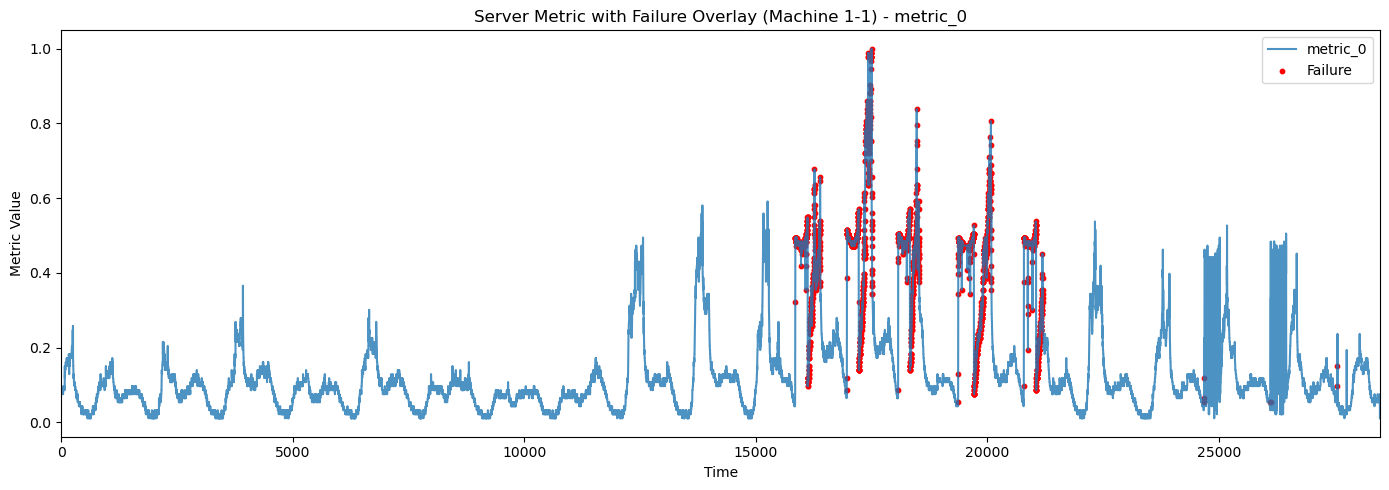

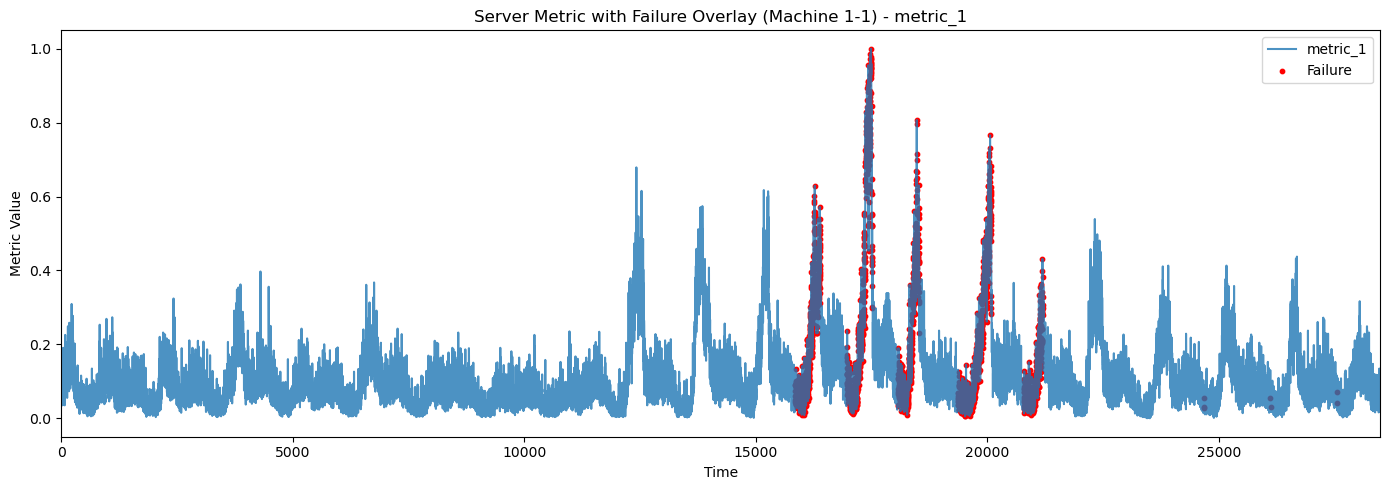

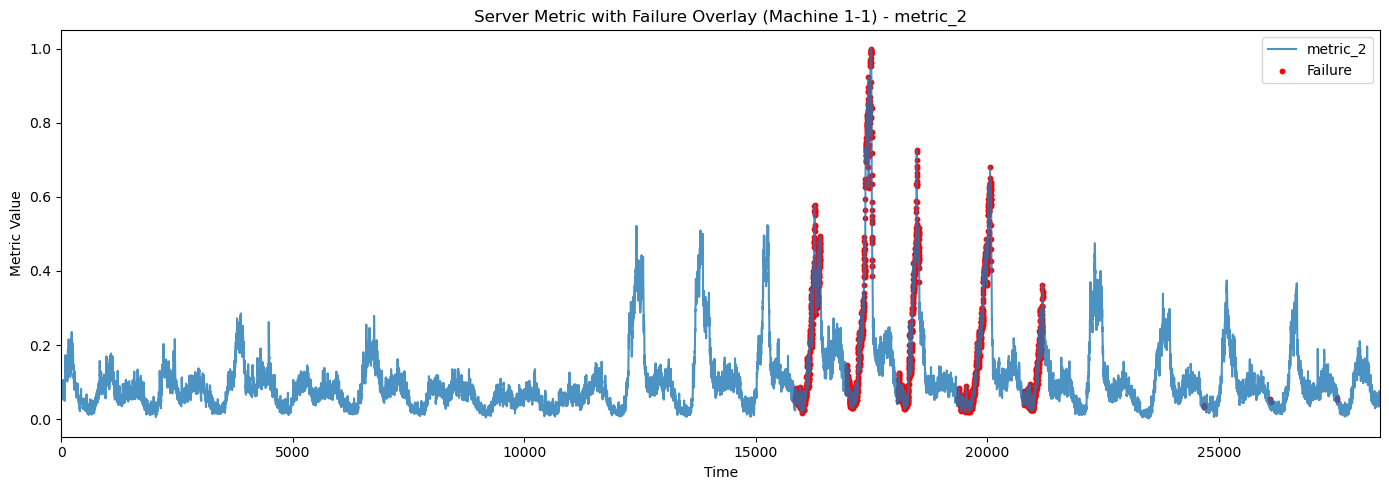

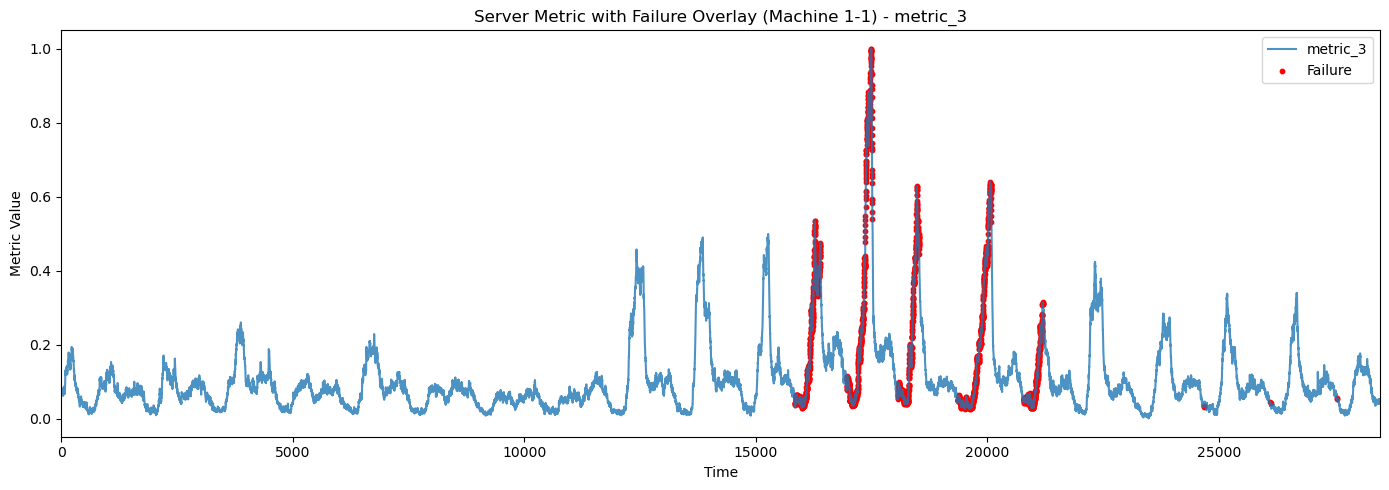

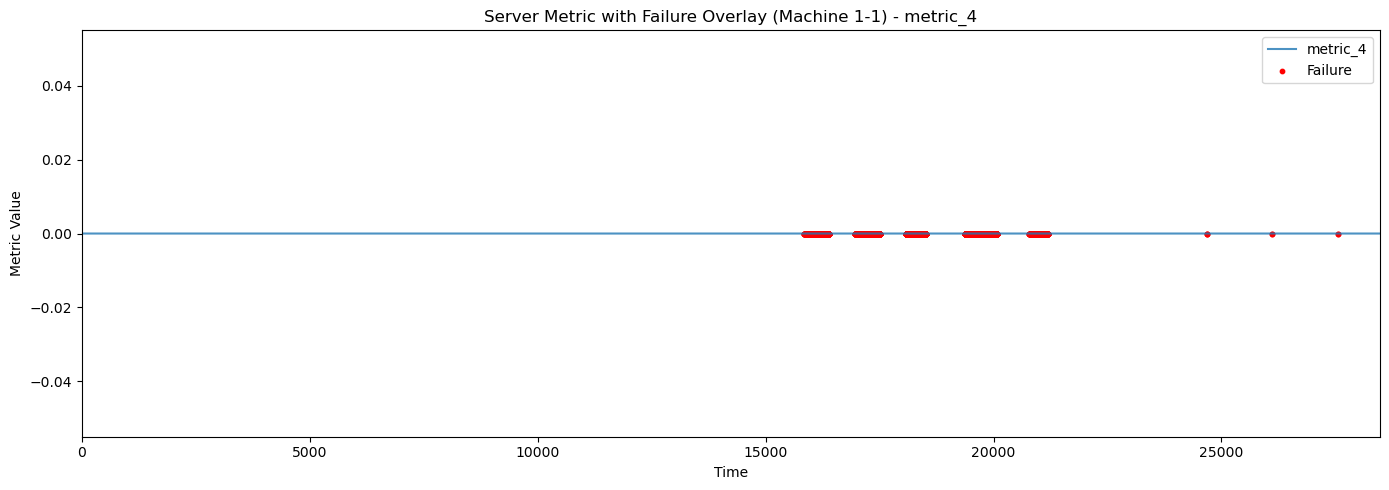

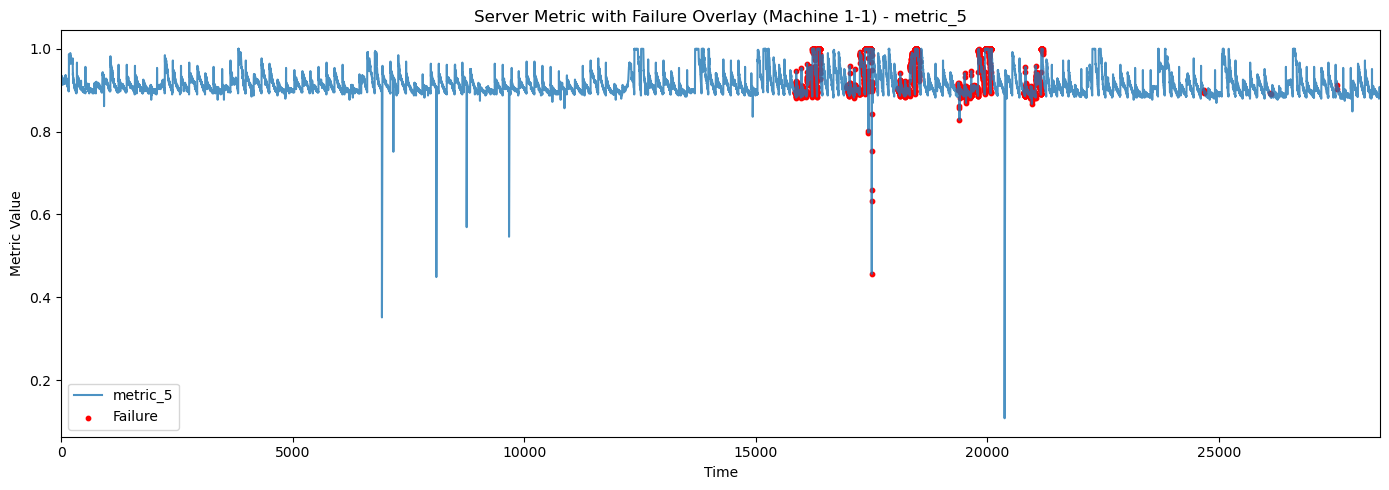

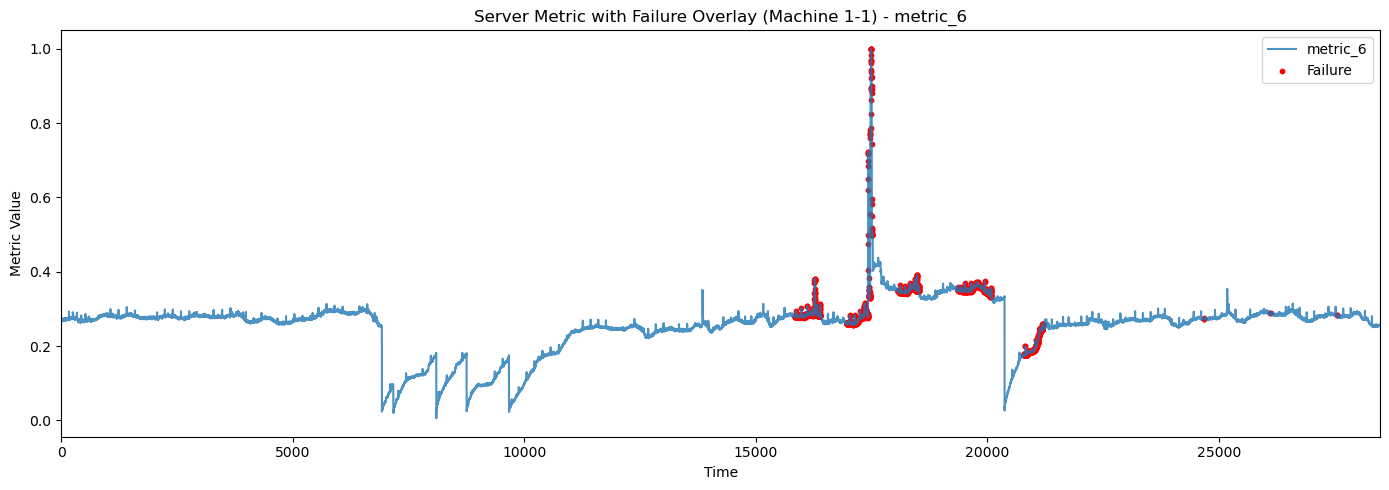

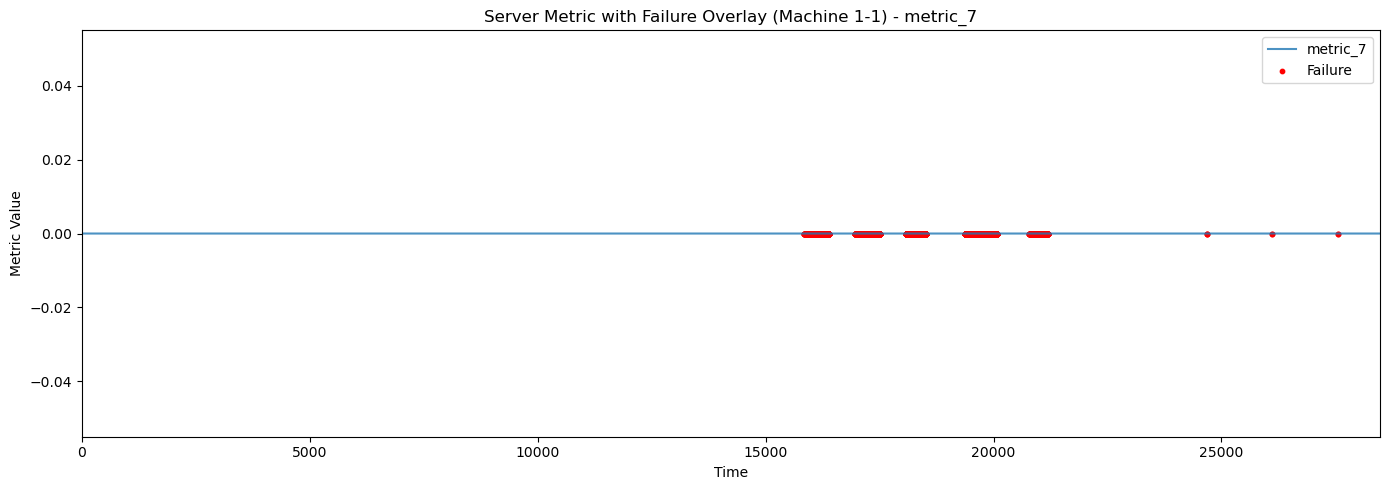

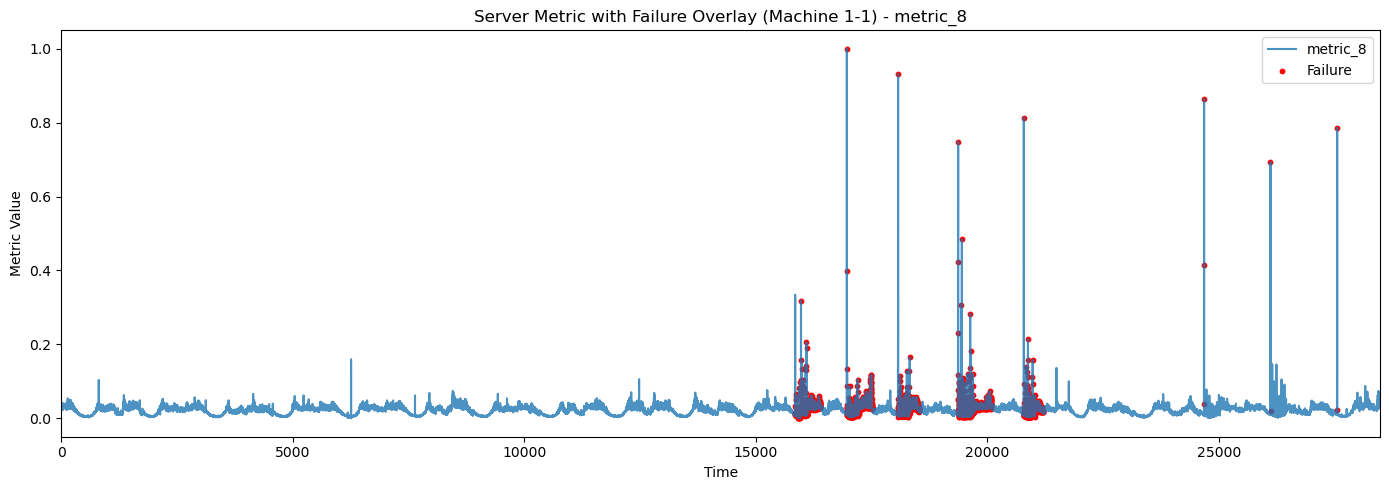

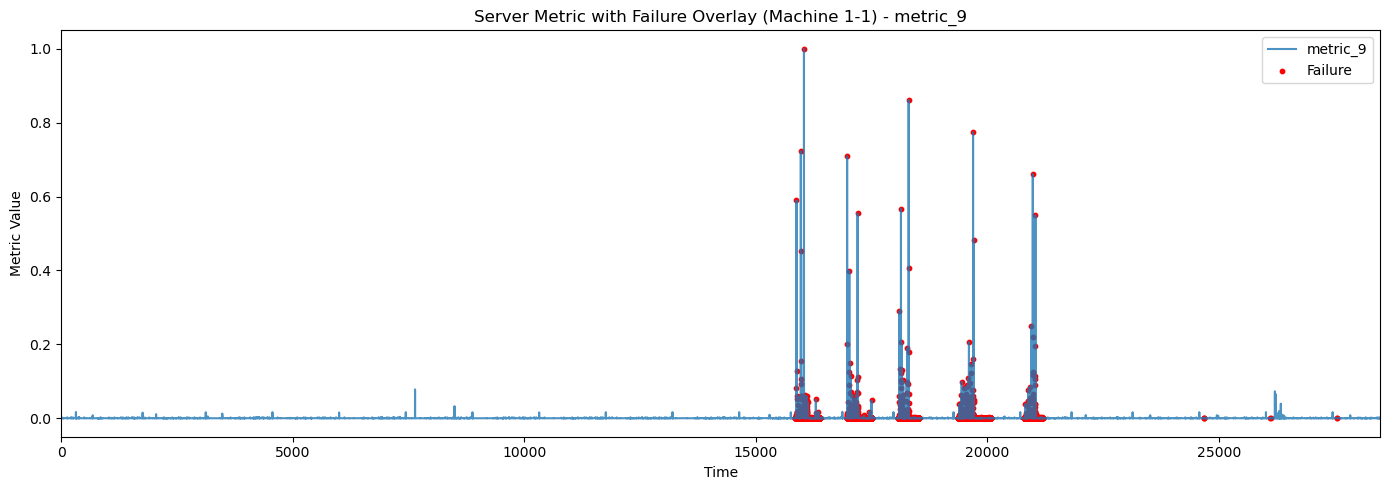

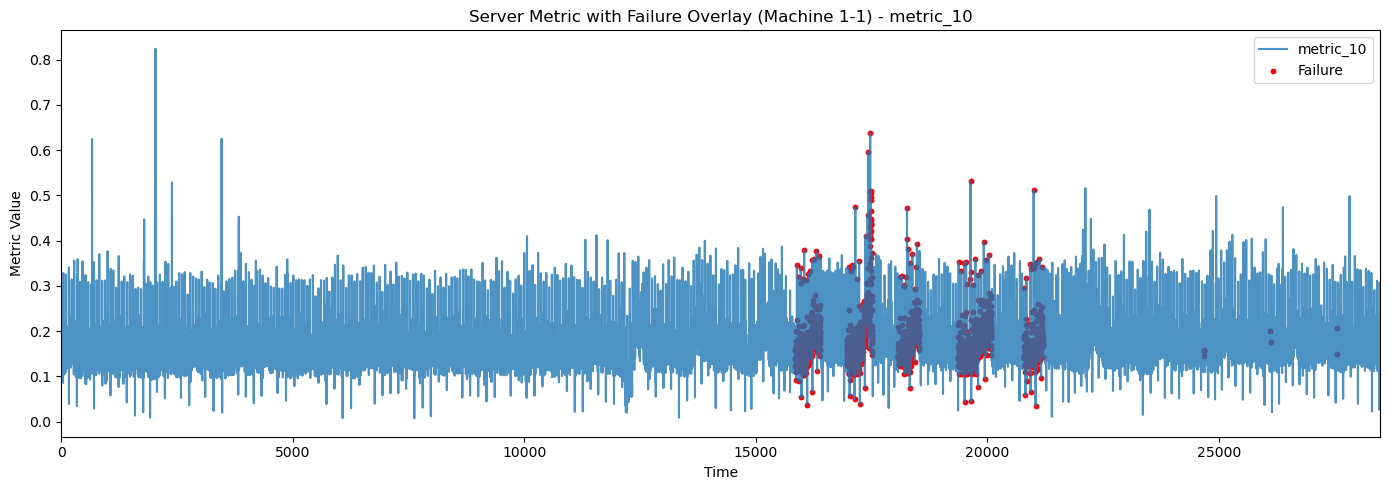

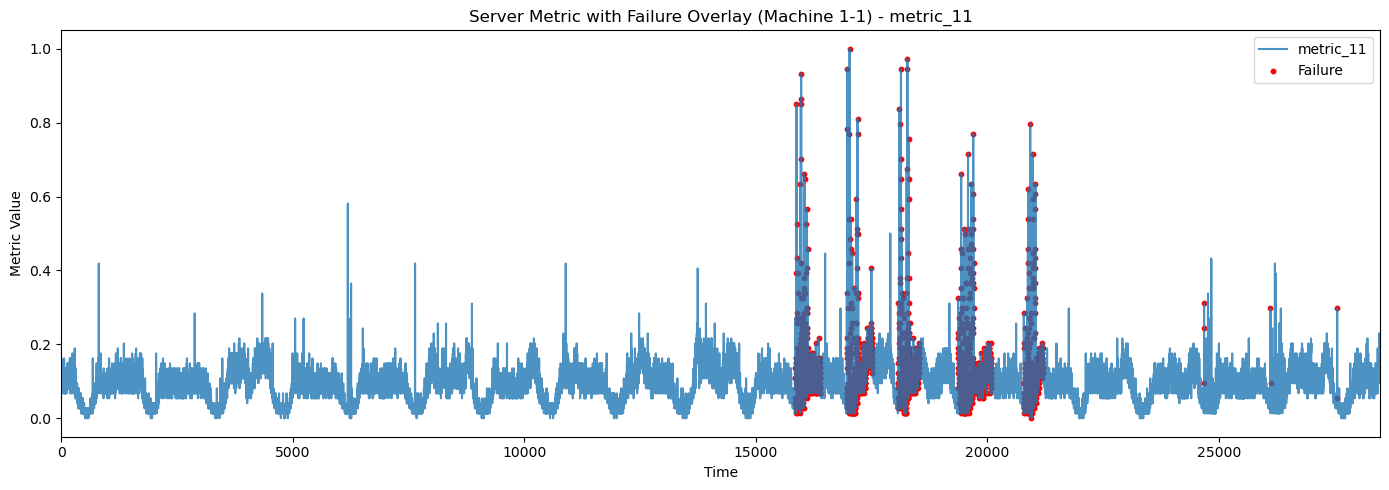

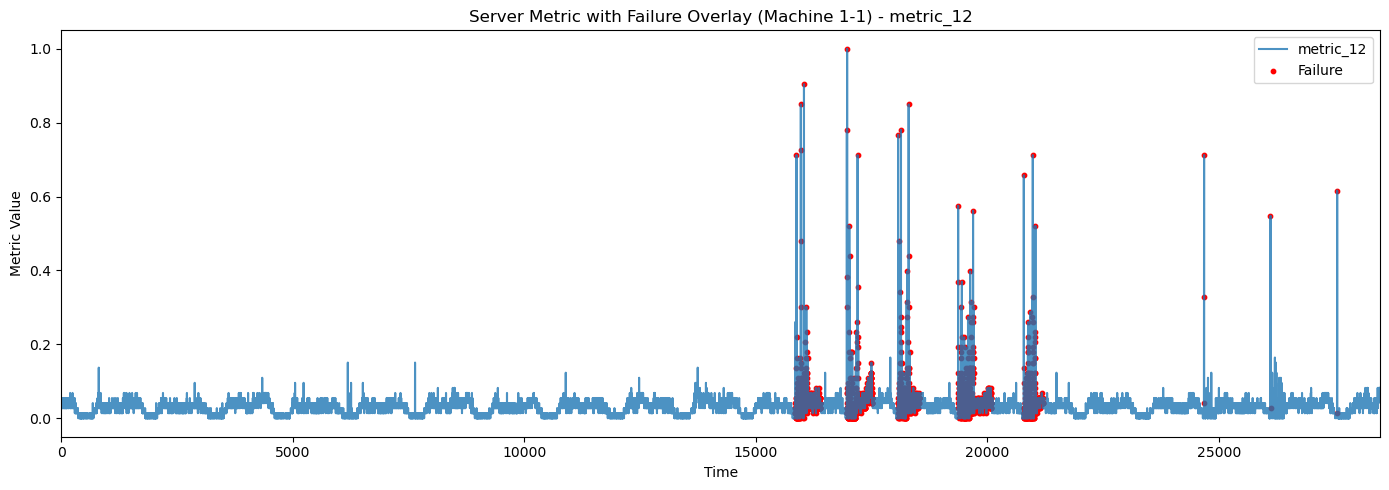

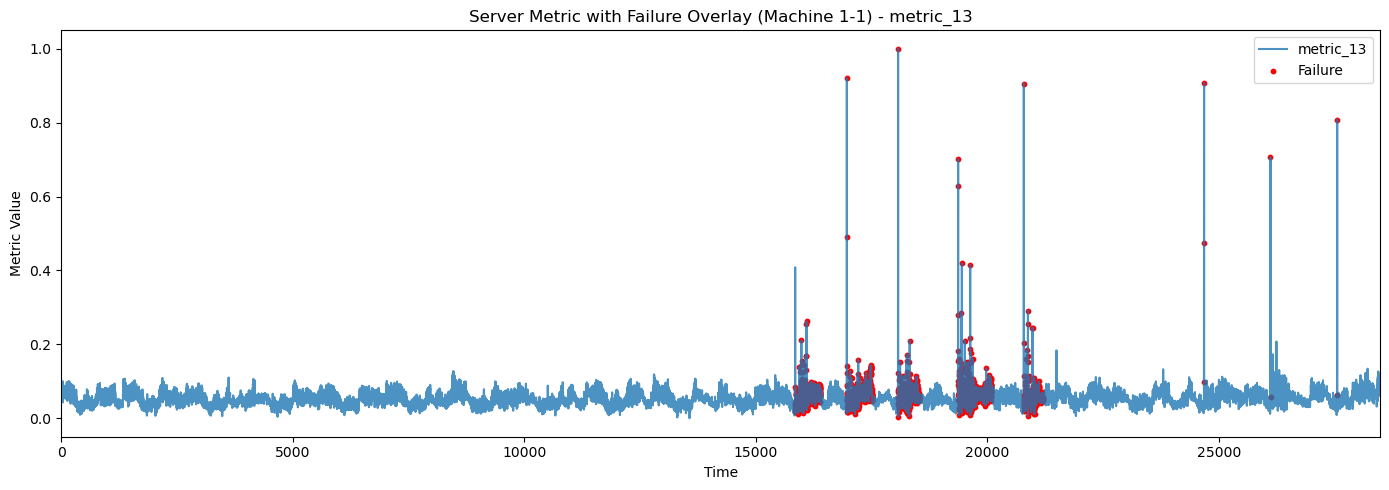

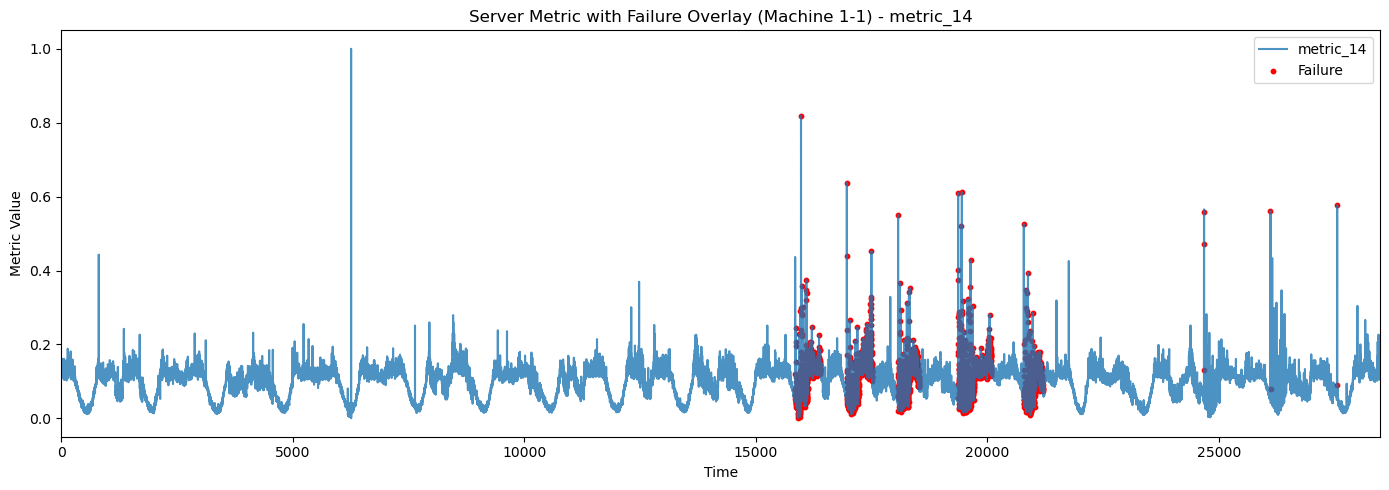

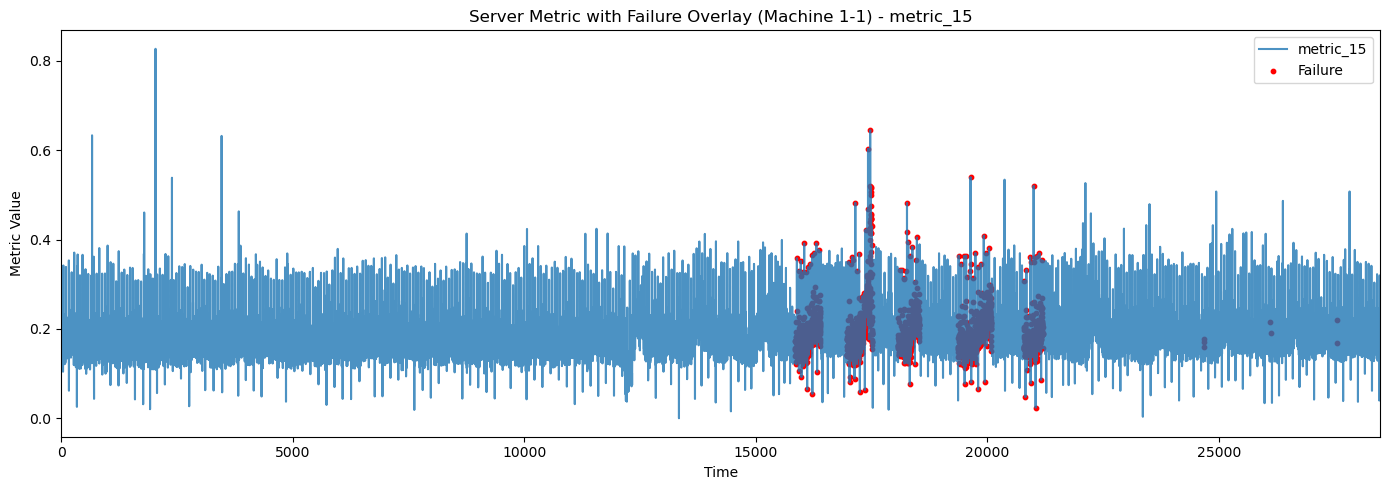

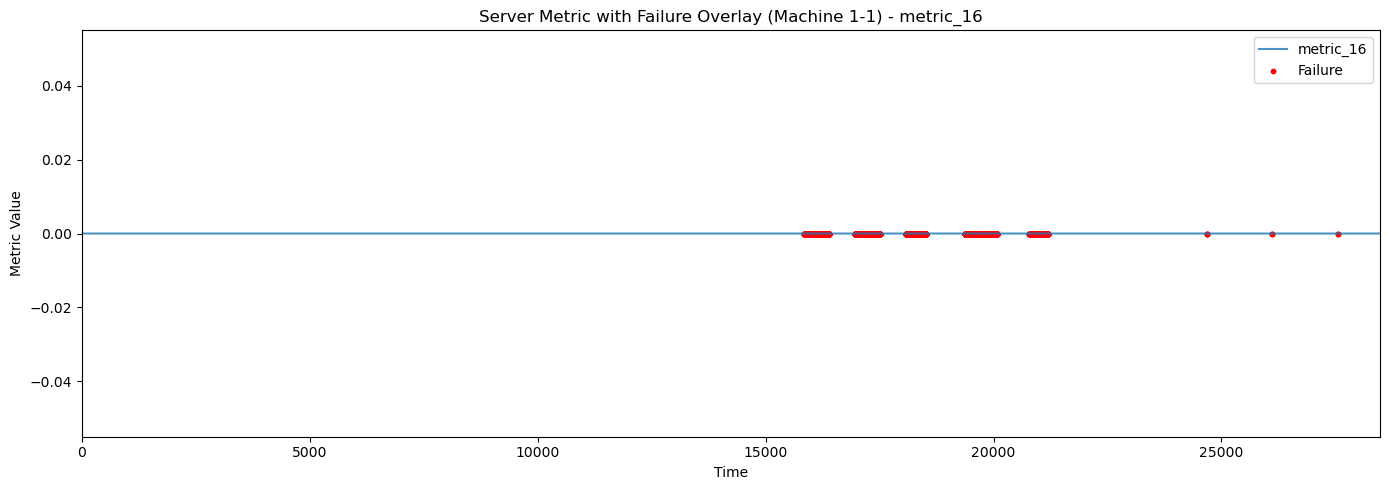

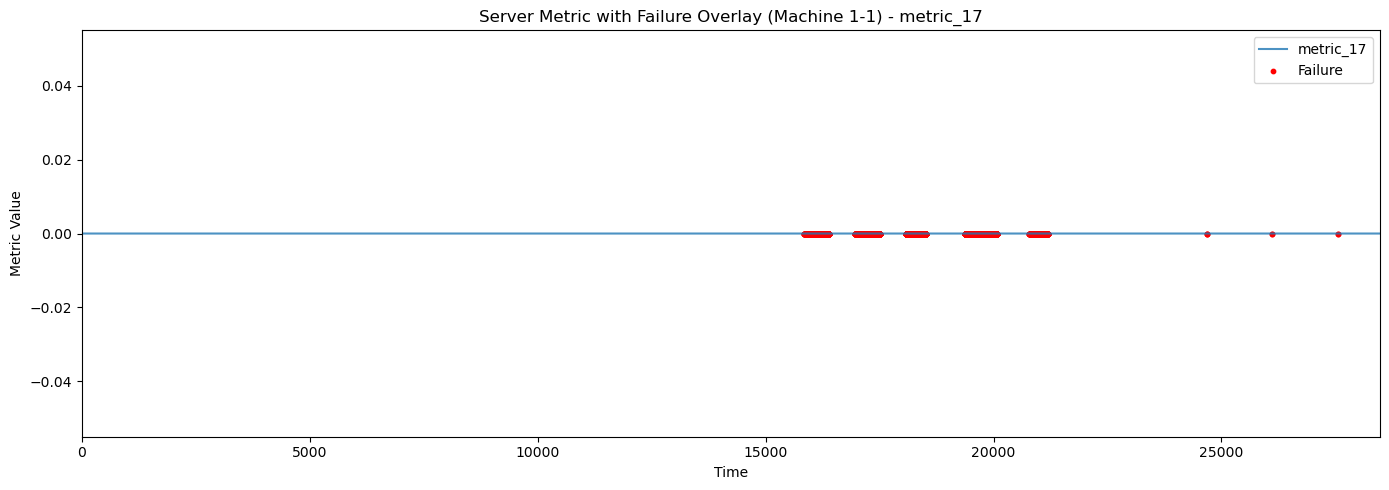

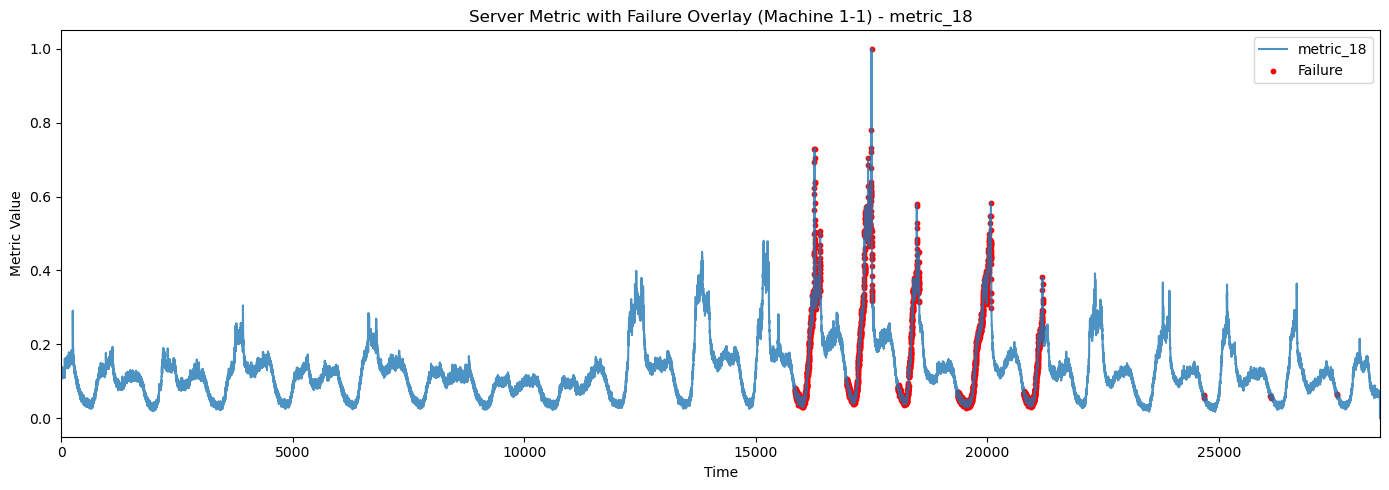

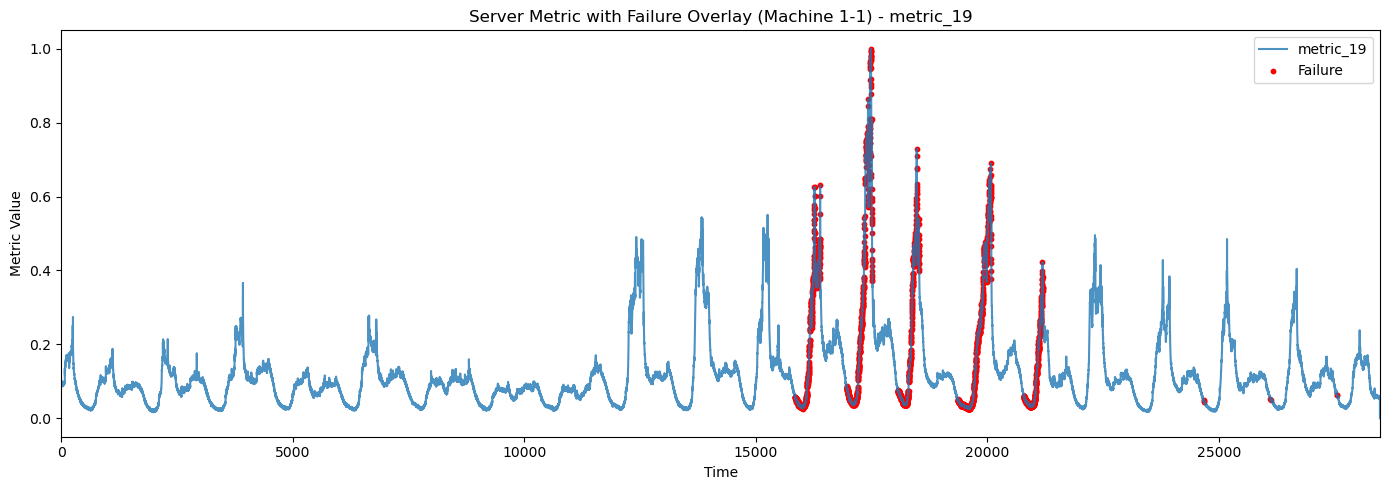

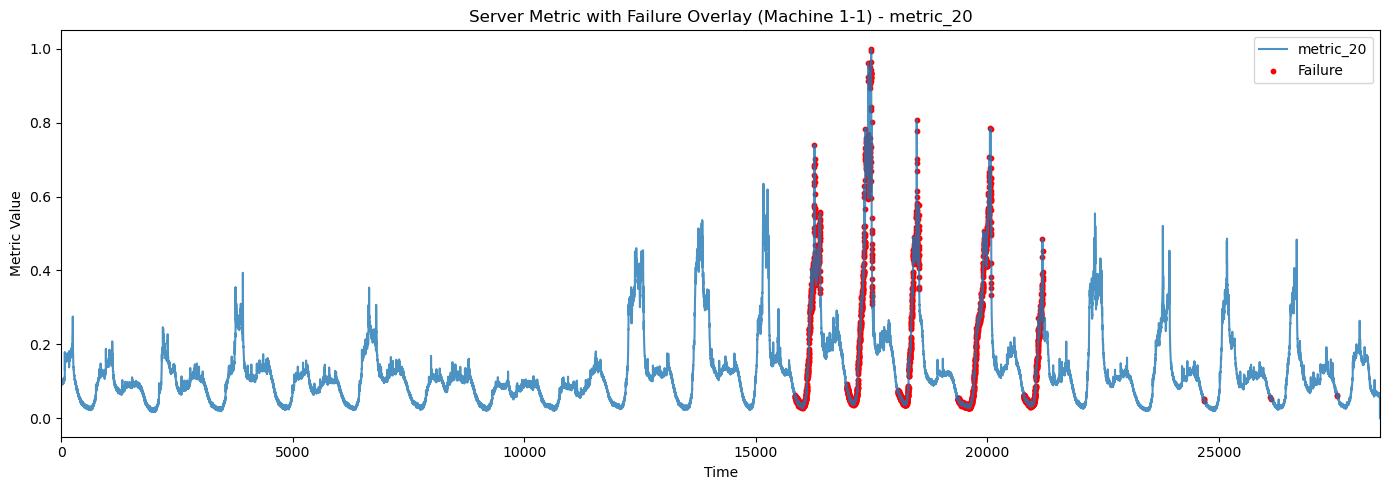

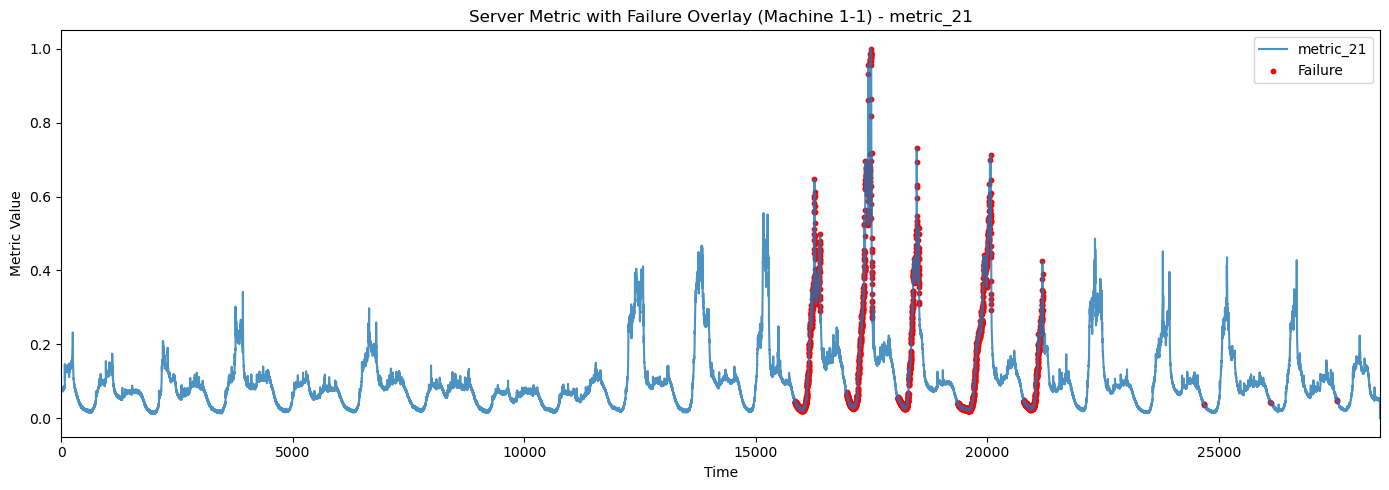

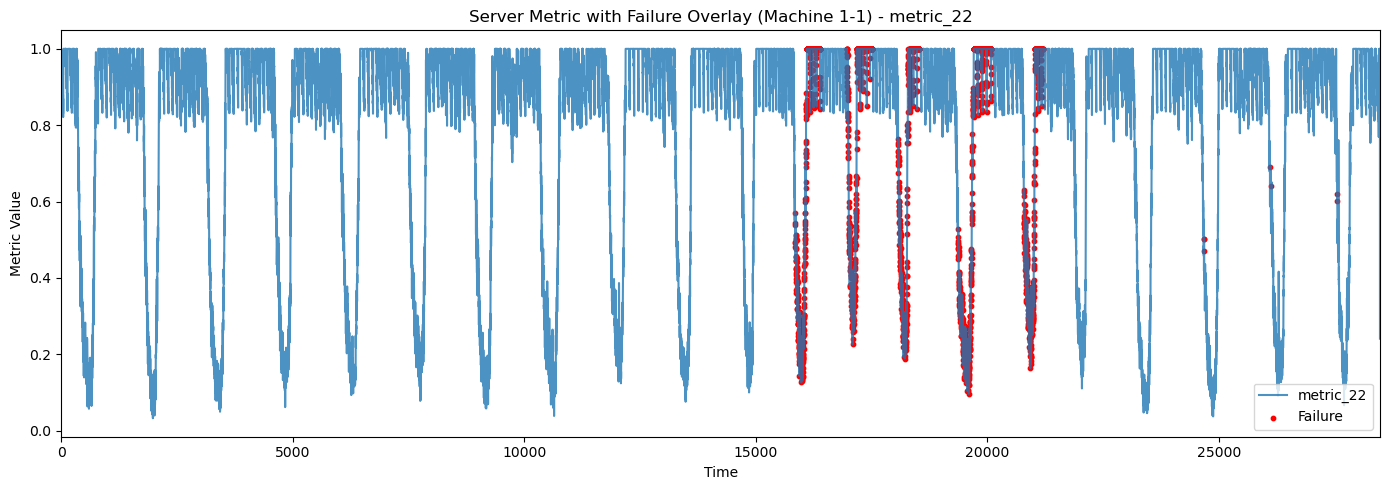

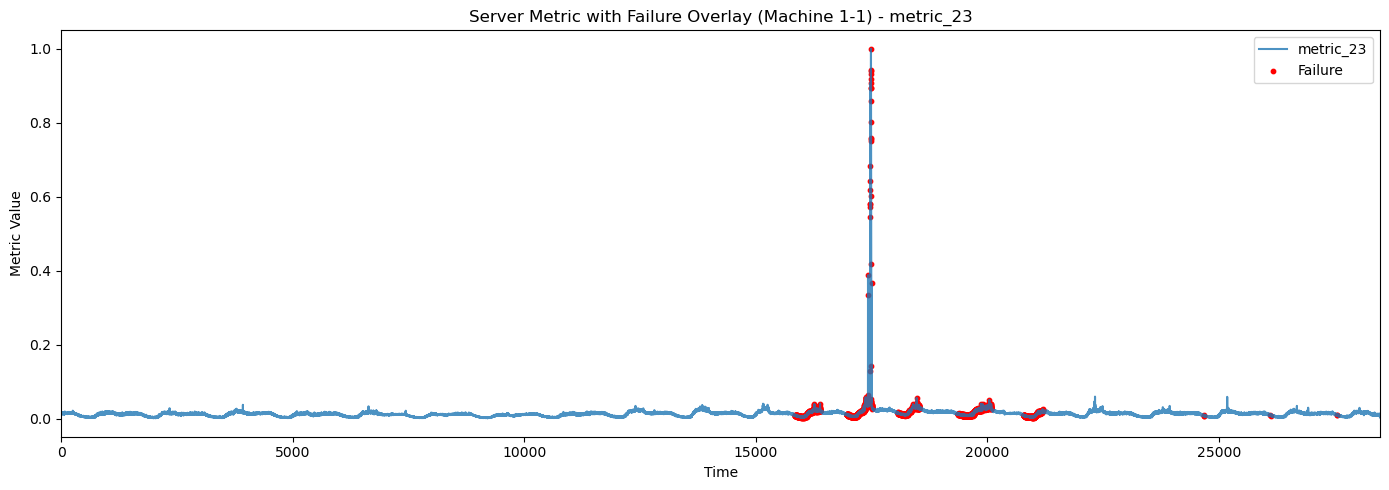

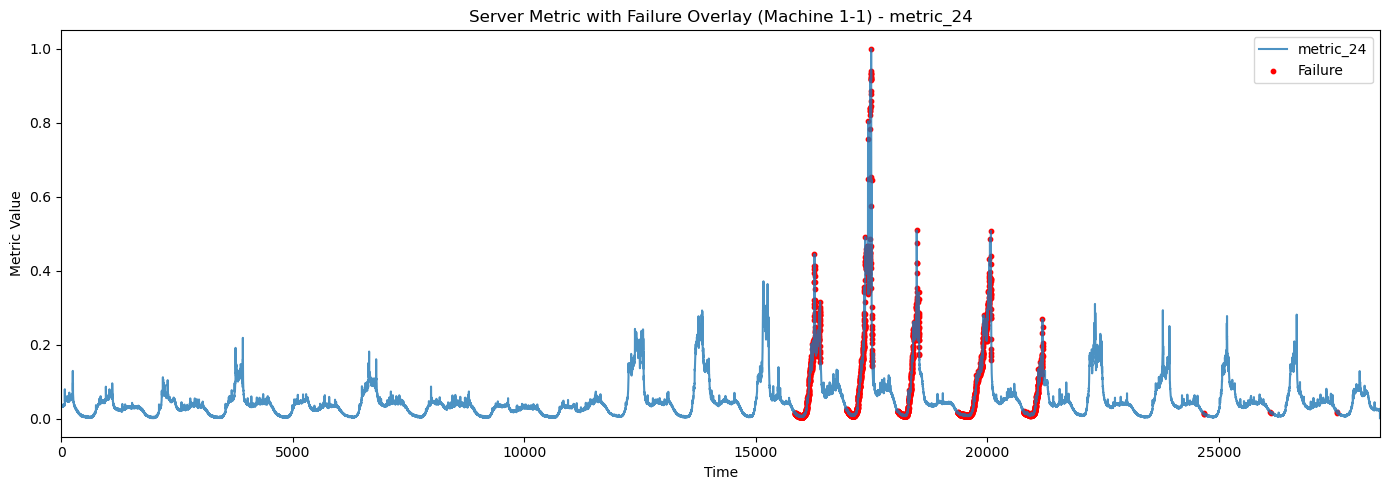

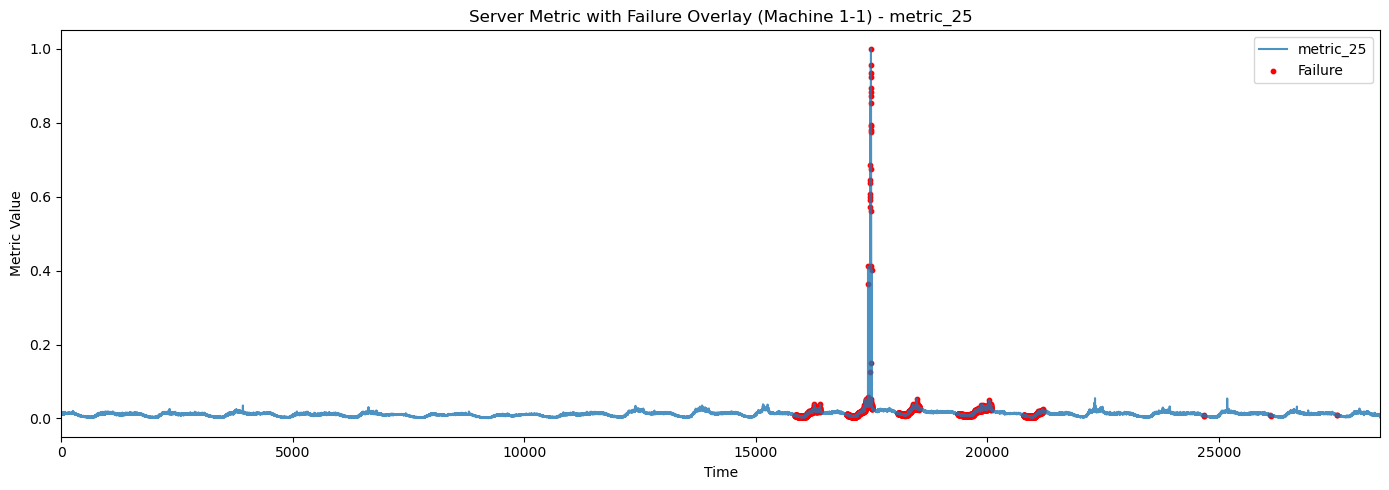

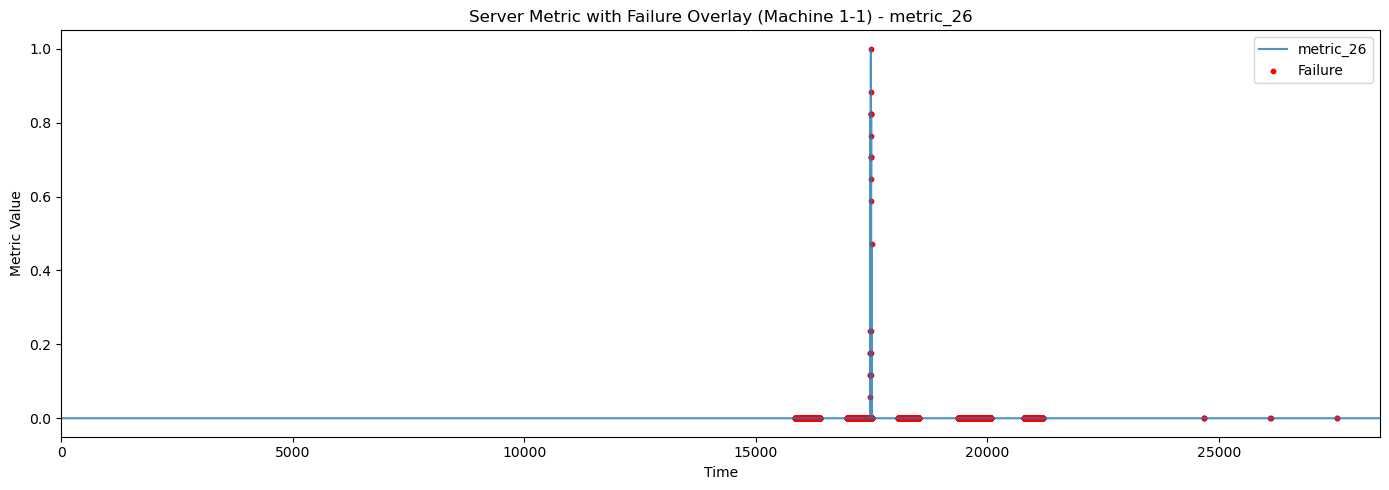

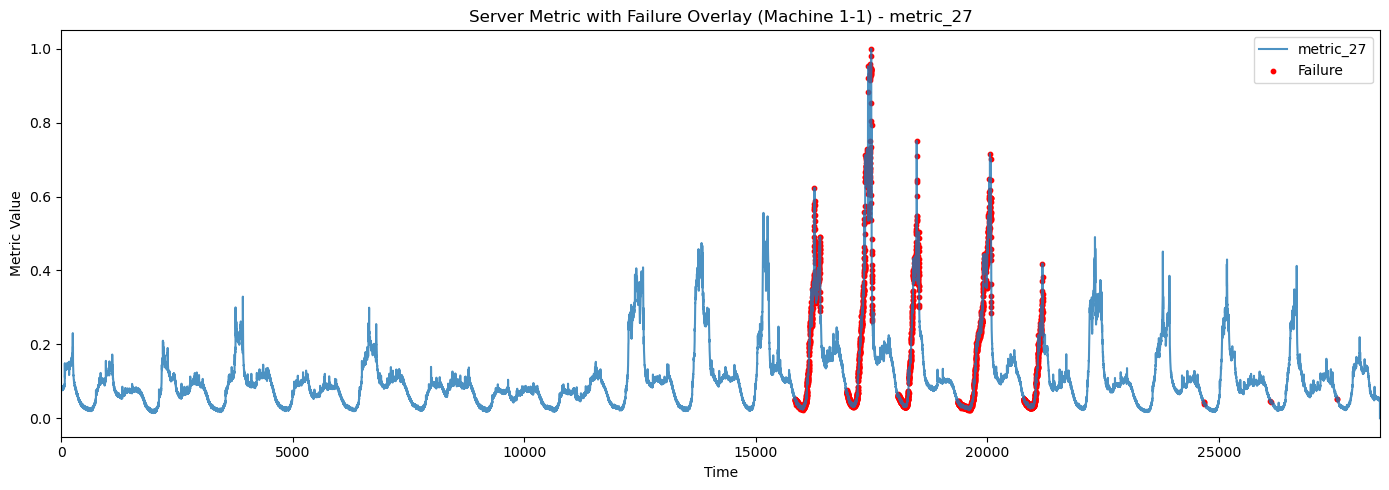

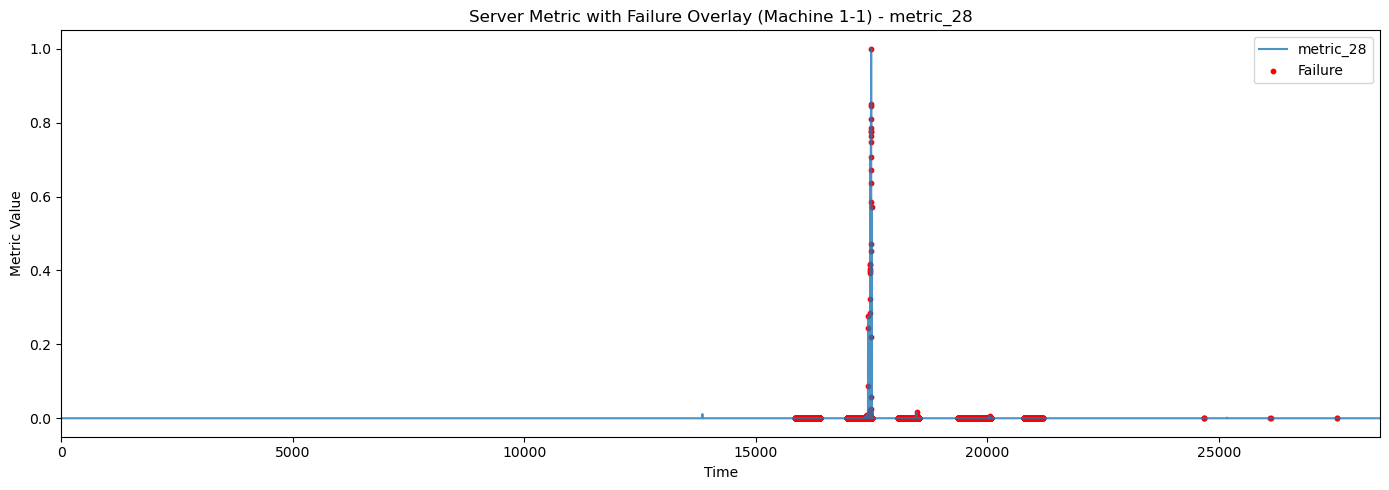

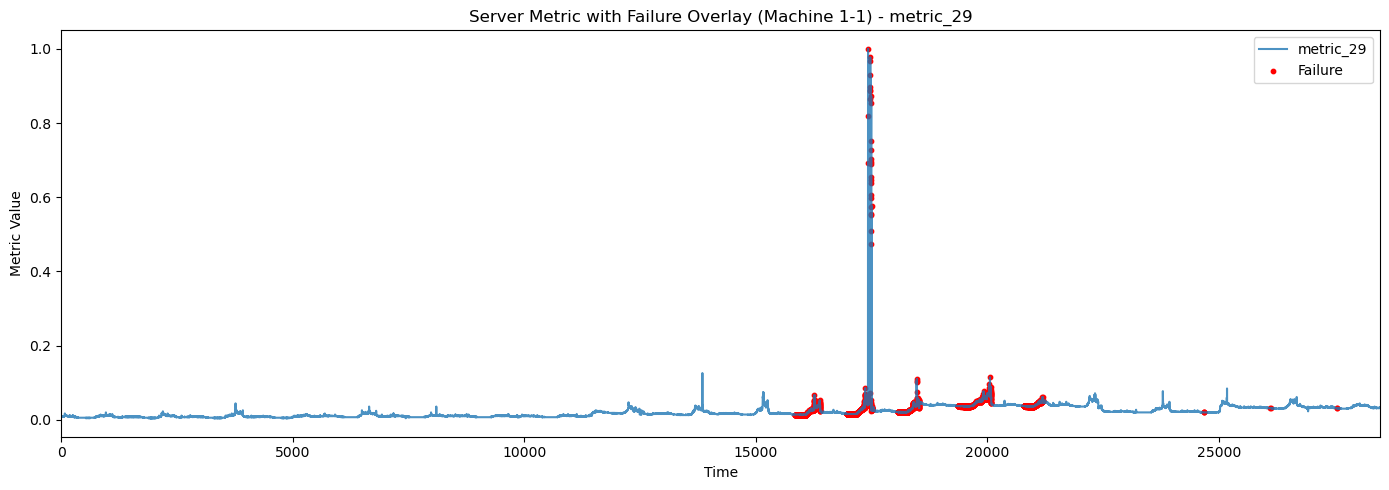

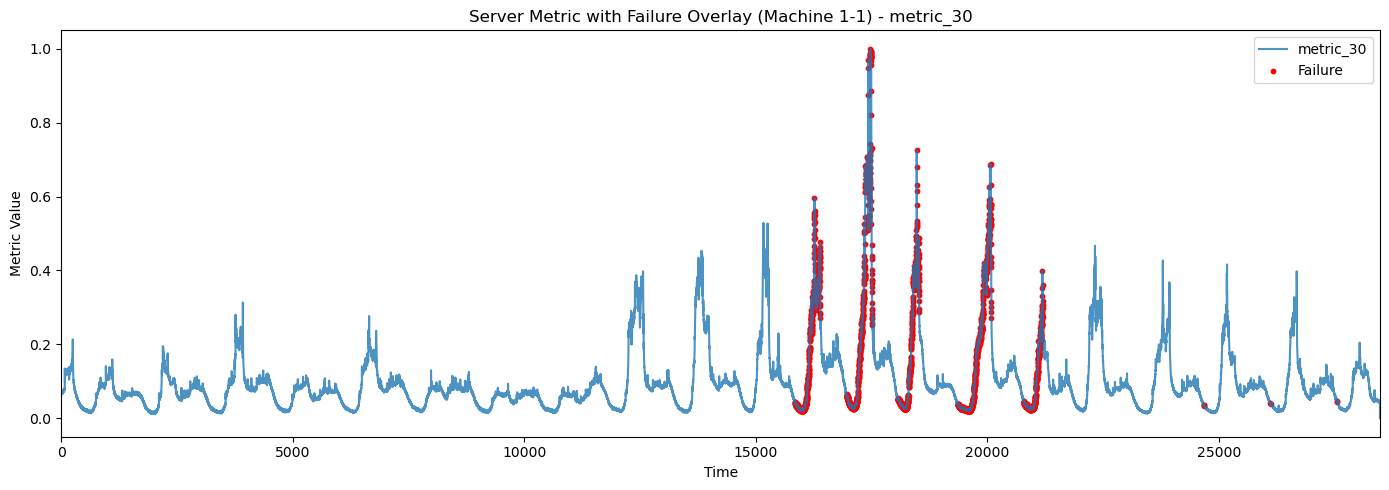

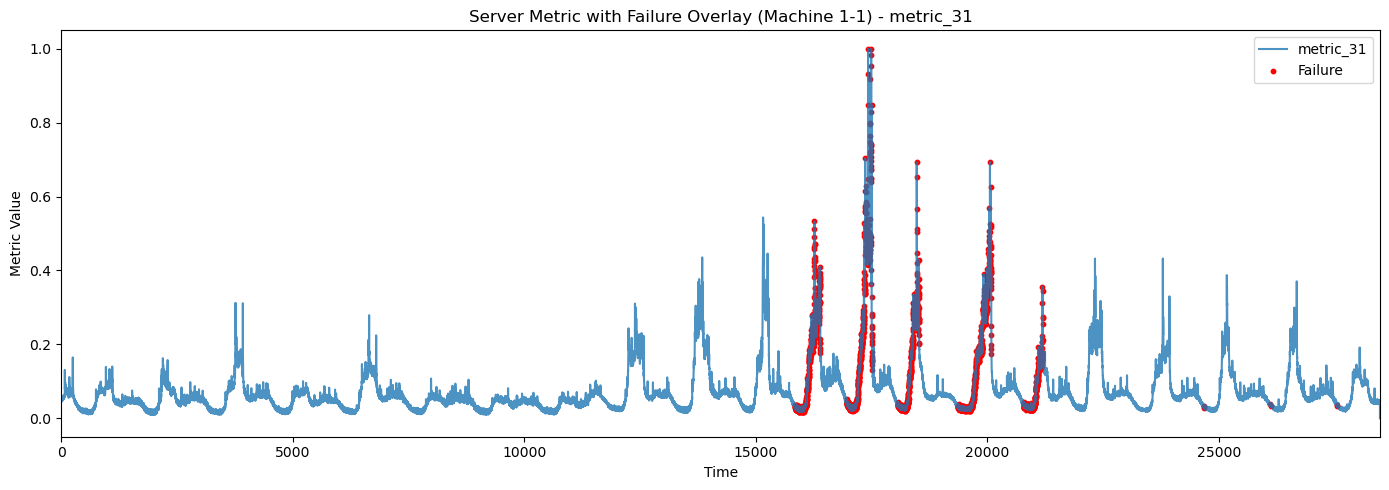

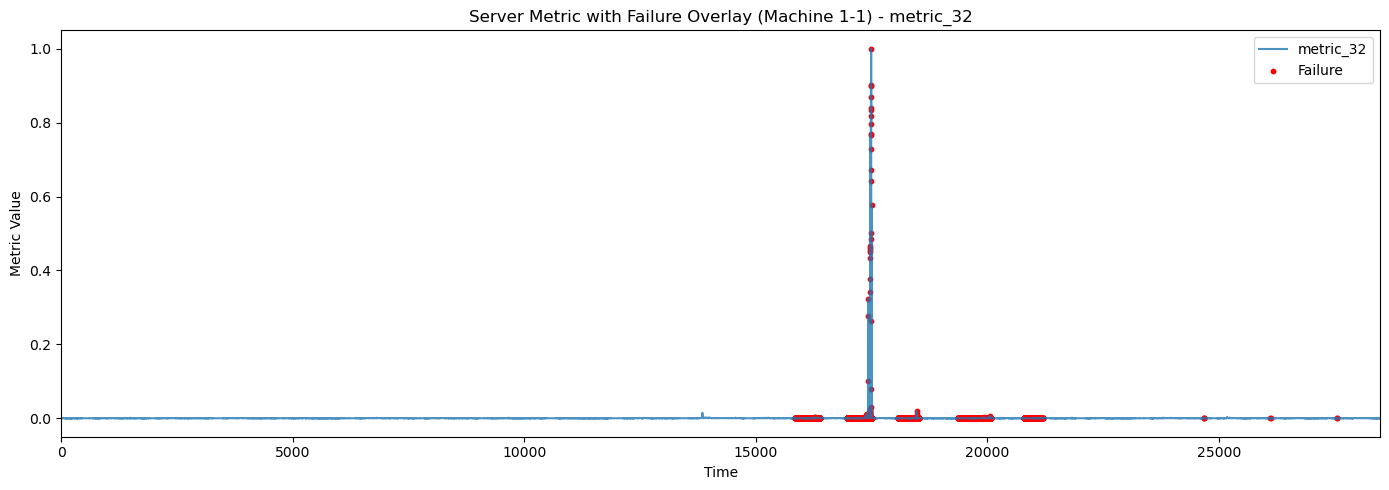

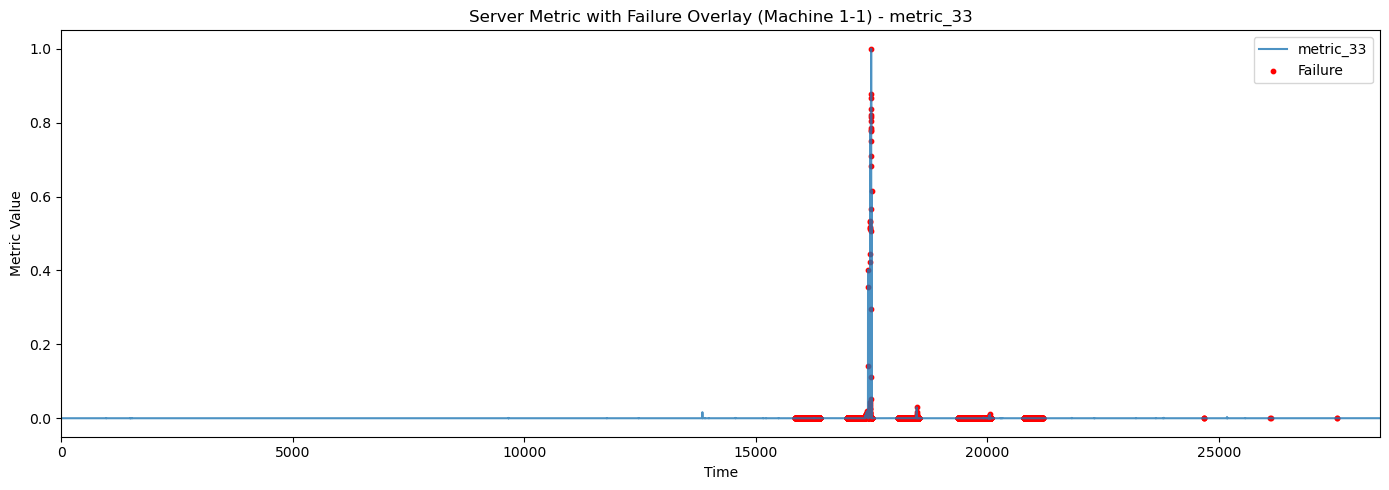

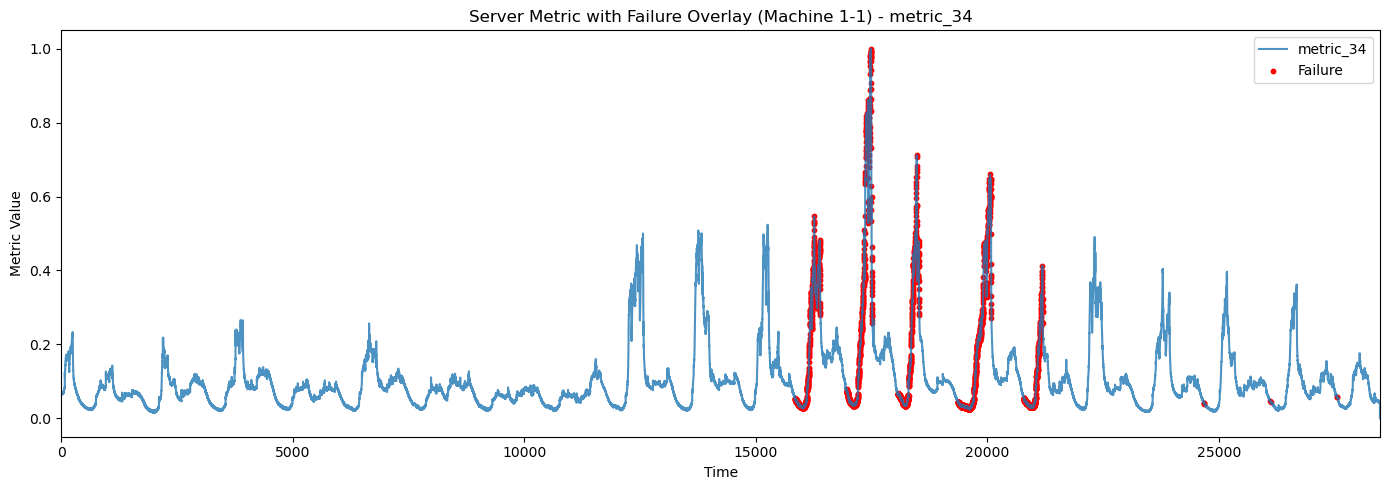

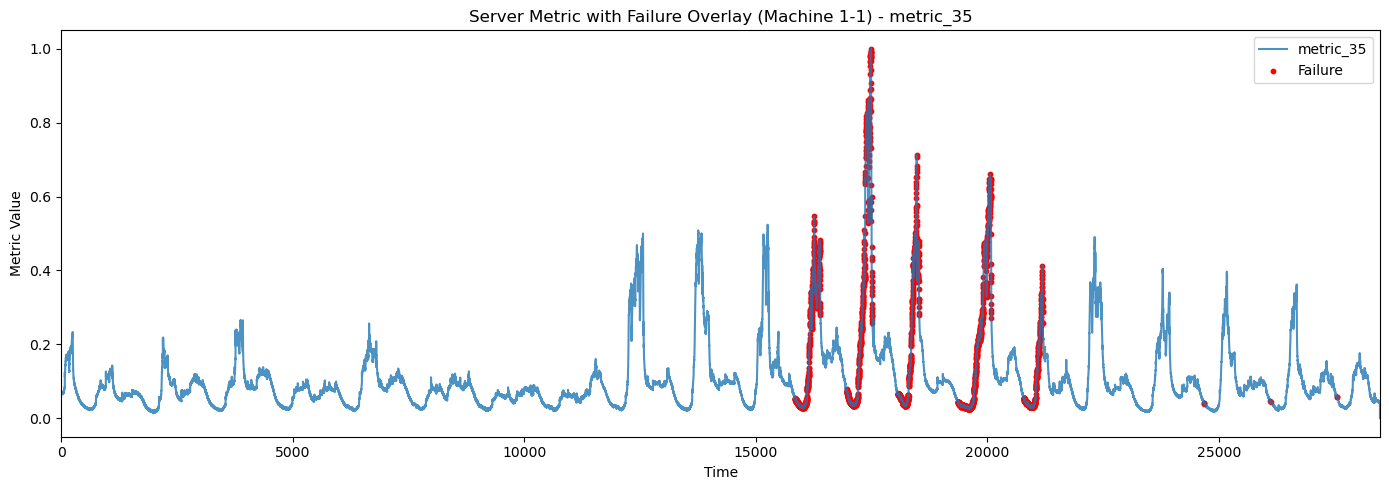

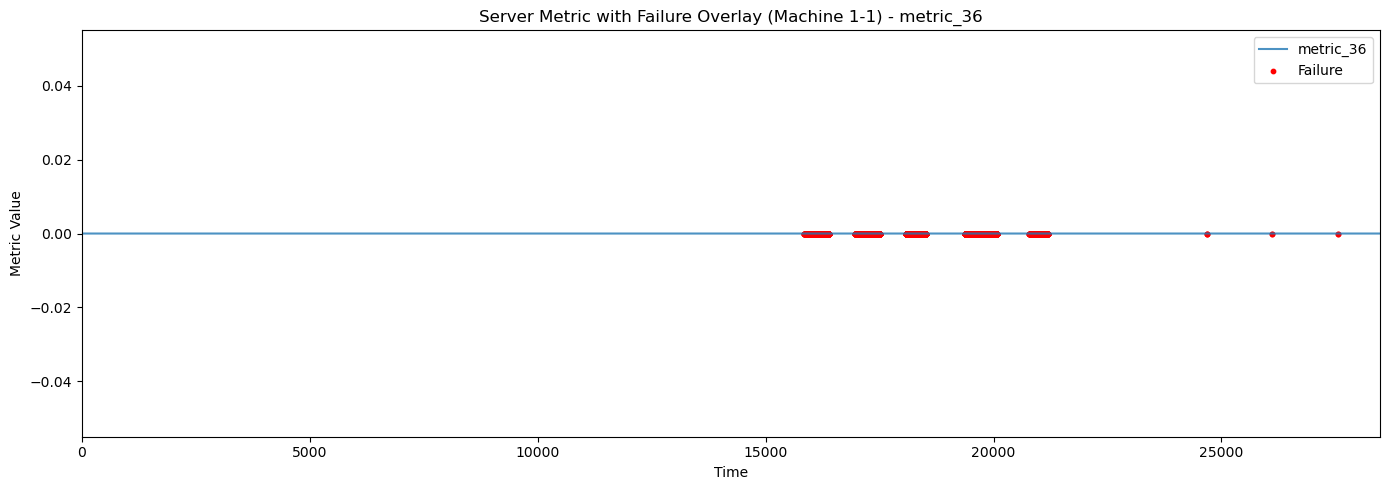

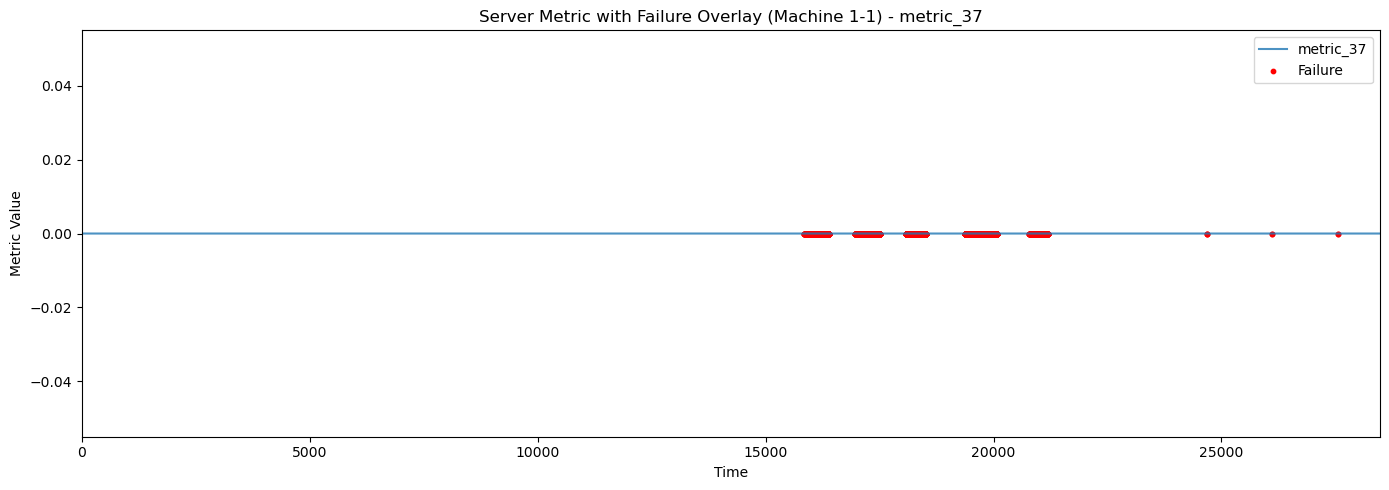

In [48]:
# Display the graph
for i in range(num_features):
    plt.figure(figsize=(14, 5))

    plt.plot(test_df.index, test_df[f"metric_{i}"], label=f"metric_{i}", alpha=0.8)

    # Highlight anomaly regions
    anomalies = test_df[test_df["is_anomaly"] == 1]
    plt.scatter(
        anomalies.index,
        anomalies[f"metric_{i}"],
        color="red",
        label="Failure",
        s=10
    )


    plt.title(f"Server Metric with Failure Overlay (Machine 1-1) - metric_{i}")
    plt.xlim(0, train_df.shape[0]) # Set x-axis limits to the range of our data
    plt.xlabel("Time")
    plt.ylabel("Metric Value")
    plt.legend()
    plt.tight_layout()

### Step 3: Feature Engineering 

In [55]:
def create_time_features(df, metrics, window=10, lag=5):
    df_feat = df.copy()

    for col in metrics:
        df_feat[f"{col}_roll_mean"] = df_feat[col].rolling(window).mean()
        df_feat[f"{col}_roll_std"] = df_feat[col].rolling(window).std()
        df_feat[f"{col}_lag_{lag}"] = df_feat[col].shift(lag)

    return df_feat

In [56]:
selected_metrics = ["metric_0", "metric_1", "metric_2"]

train_feat = create_time_features(train_df, selected_metrics)
test_feat = create_time_features(test_df, selected_metrics)


In [57]:
train_feat = train_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

In [58]:
X_train = train_feat
X_test = test_feat.drop(columns=["is_anomaly"])
y_test = test_feat["is_anomaly"]

In [59]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


NameError: name 'MinMaxScaler' is not defined

In [60]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

NameError: name 'X_train_scaled' is not defined

### Step 4: Model Training

In [61]:
split_idx = int(len(X_test_scaled) * 0.7)

X_train_time = X_test_scaled.iloc[:split_idx]
y_train_time = y_test.iloc[:split_idx]

X_test_time = X_test_scaled.iloc[split_idx:]
y_test_time = y_test.iloc[split_idx:]


NameError: name 'X_test_scaled' is not defined

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",   
    random_state=42,
    n_jobs=-1
)


### Step 5: Evaluation

In [ ]:
y_pred = rf.predict(X_test_time)
y_pred_proba = rf.predict_proba(X_test_time)[:, 1]


In [ ]:
recall = recall_score(y_test_time, y_pred)
precision = precision_score(y_test_time, y_pred)

print(f"Recall:    {recall:.3f}")
print(f"Precision: {precision:.3f}")

In [ ]:
print(classification_report(y_test_time, y_pred, digits=3))


In [ ]:
# Convert to numpy for speed
y_true_array = y_test_time.values

# First occurrence of failure
true_failure_idx = np.where(y_true_array == 1)[0][0]


In [ ]:
y_pred_array = y_pred

pred_failure_indices = np.where(y_pred_array == 1)[0]

if len(pred_failure_indices) == 0:
    print("⚠️ Model never raised an alarm.")
    lead_time = None
else:
    pred_failure_idx = pred_failure_indices[0]


In [ ]:
lead_time_steps = true_failure_idx - pred_failure_idx
print("Lead time (steps):", lead_time_steps)


In [ ]:
lead_time_seconds = lead_time_steps
lead_time_minutes = lead_time_seconds / 60

print(f"Lead Time: {lead_time_seconds} seconds ({lead_time_minutes:.2f} minutes)")


In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(X_test_time.index, X_test_time["metric_0"], label="Metric 0")

# Actual failure
plt.axvline(
    X_test_time.index[true_failure_idx],
    color="red",
    linestyle="--",
    label="Actual Failure"
)

# Predicted failure
if len(pred_failure_indices) > 0:
    plt.axvline(
        X_test_time.index[pred_failure_idx],
        color="orange",
        linestyle="--",
        label="Predicted Failure"
    )

plt.legend()
plt.title("Early Failure Detection (Lead-Time Visualization)")
plt.tight_layout()
plt.show()
